In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import seaborn as sns

In [4]:
#datasets
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [5]:
tips = sns.load_dataset("tips")
iris = sns.load_dataset("iris")
titanic = sns.load_dataset("titanic")
planets = sns.load_dataset("planets")

In [6]:
tips


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='tip', ylabel='total_bill'>

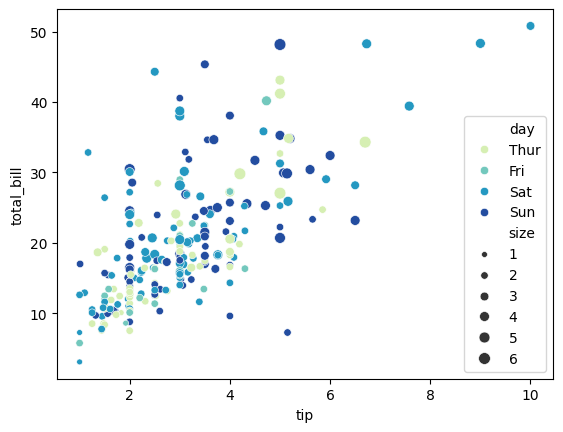

In [19]:
#creating scatterplot
#syntax =  sns.scatterplot(x="", y='', data=name_of_dataset)

sns.scatterplot(x = "tip", y = "total_bill", 
                data = tips, 
                hue = "day", 
                size = "size",
               palette = "YlGnBu")

### Different Palettes in Seaborn

#### **1. Qualitative Palettes**
    deep: The default Seaborn palette; rich, vibrant colors.
    muted, pastel, bright, dark: Variations in saturation and brightness.
    colorblind: Specifically optimized for accessibility and color vision deficiencies.
#### **2. Sequential Palettes**
    rocket, mako, flare, crest: Perceptually uniform palettes, ideal for heatmaps and standard plots.
    Blues, Greens, Reds: Single-hue color maps that smoothly scale in saturation
#### **3. Diverging Palettes**
    vlag: Strong transition from muted red to muted blue.
    icefire: Smooth, visually striking transition from deep blue to vibrant orange/red.
    RdBu, BrBG: Classic diverging colormaps from Matplotlib

<Axes: xlabel='tip', ylabel='Count'>

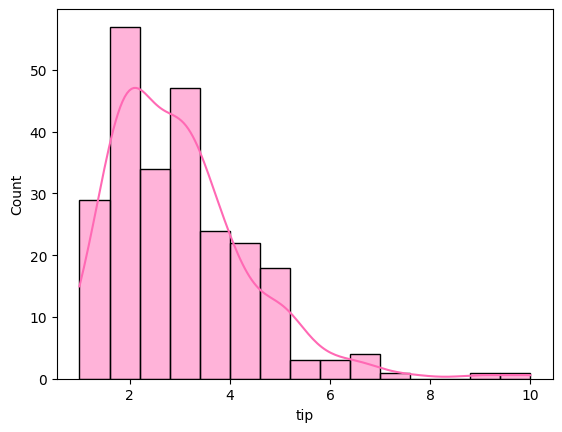

In [21]:
#KDE stands for Kernel Density Estimation.
# In Seaborn, it is a statistical technique used to visualize the probability distribution
# of continuous data as a smooth, continuous curve, 
# rather than discrete, blocky bars like you would see 
# in a standard histogram.


sns.histplot(tips['tip'], 
             kde = True,
             bins = 15, 
             color = 'hotpink')

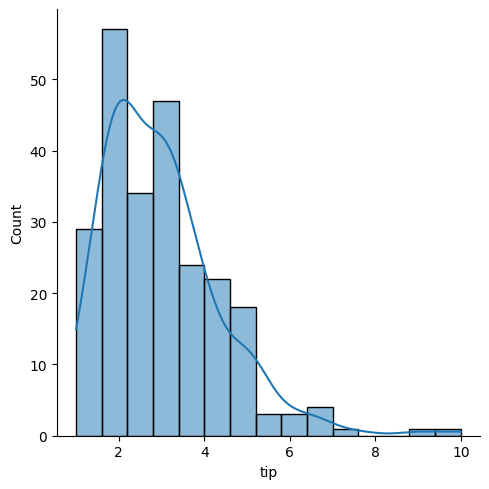

In [23]:
#different way

#distplot = distribtution plot

sns.displot(tips['tip'], 
             kde = True,
             bins = 15)

<Axes: xlabel='sex', ylabel='tip'>

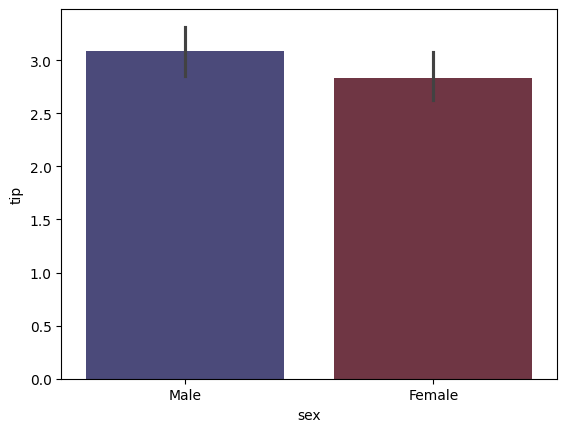

In [29]:
#barplots

sns.barplot(x = "sex", y = "tip", data=tips, hue = 'sex', legend = False,  palette="icefire")

<Axes: xlabel='day', ylabel='tip'>

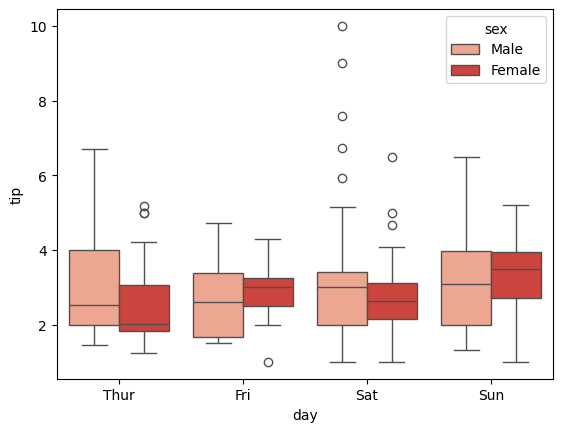

In [34]:
#boxplot
sns.boxplot(x="day", y="tip", data=tips, hue = "sex", palette="Reds")

<Axes: xlabel='day', ylabel='tip'>

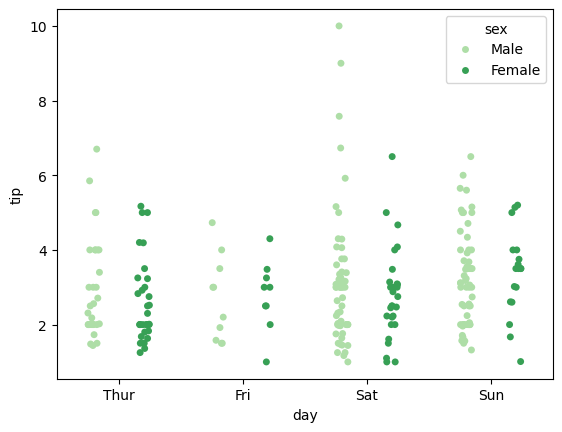

In [39]:
#stripplot

#if no dodge then the data points for x are in the same strip
sns.stripplot(x="day", y="tip", data = tips,
              dodge = True, 
              hue="sex", 
              palette="Greens")

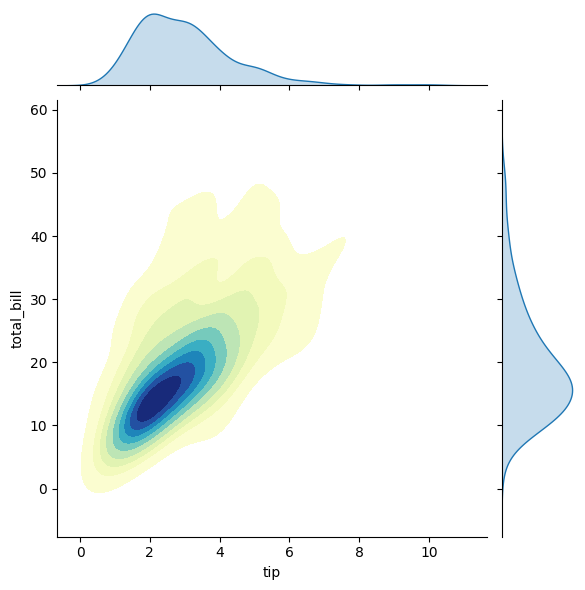

In [47]:
#joint plots---scatterplots and distrbution plots

sns.jointplot(x="tip", y="total_bill", data =tips
             , kind = "kde", fill = True, cmap="YlGnBu") #reg=regression, hex=heaxagons(no fill to be used here)

#shade is deprecated use fill instead

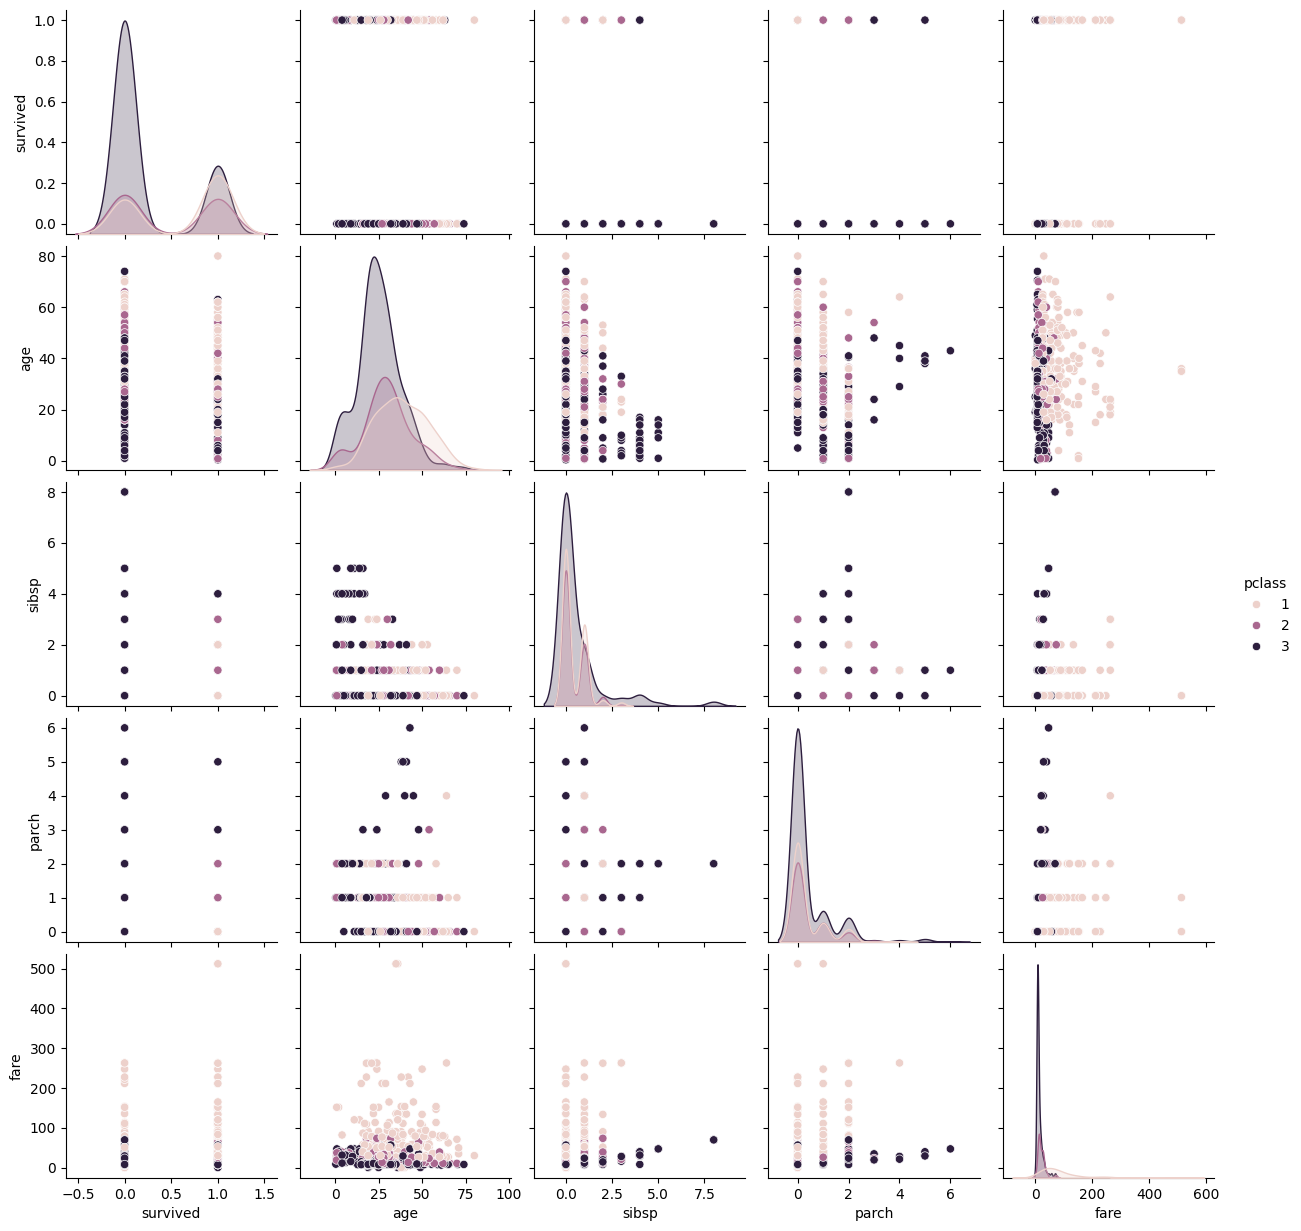

In [49]:
#pairplots

sns.pairplot(titanic.select_dtypes(["number"]), hue = "pclass")

In [54]:
#for titanic we want to find survivors...
#to find which thing affected a persons survival we can find correlatio between survival and other factors
#hence df.corr() is  a good plot function

titanic.select_dtypes(include = "number").corr()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

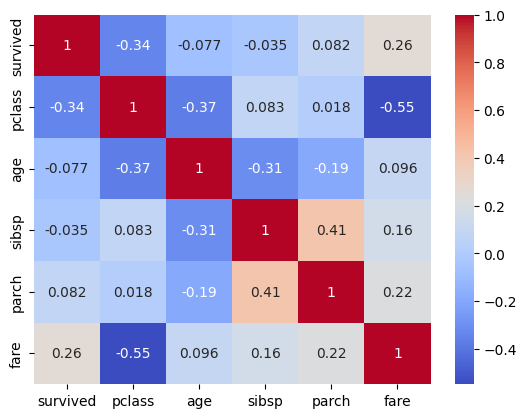

In [57]:
#for heatmap we first need to find correlation
#heatmaps are very useful to find correlation between values

sns.heatmap(titanic.select_dtypes(include = "number").corr(), annot = True, cmap="coolwarm")

In [65]:
iris.info()
iris_new = iris.copy()
iris_new = iris_new.drop(columns = ['species'])
iris_new.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


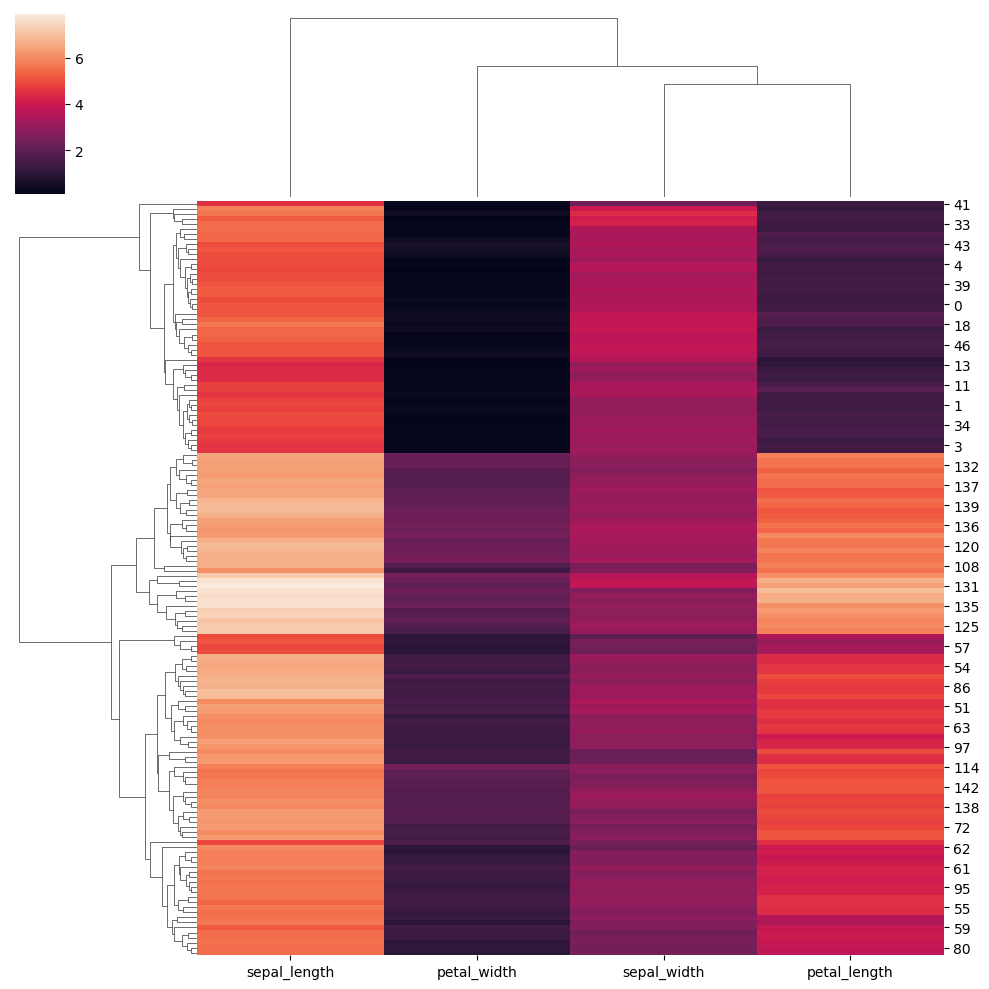

In [66]:
#clustermap is useful for finding clusters in unsupervised ML
sns.clustermap(iris_new)